In [1]:
import glob
import os
import librosa
import numpy as np

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Function to pad or truncate MFCC to a fixed sequence length
def pad_or_truncate(mfcc, max_time_steps=400):
    """Ensure all MFCCs have the same time dimension by padding or truncating."""
    if mfcc.shape[1] > max_time_steps:  # Truncate if longer
        return mfcc[:, :max_time_steps]
    elif mfcc.shape[1] < max_time_steps:  # Pad with zeros if shorter
        padding = max_time_steps - mfcc.shape[1]
        return np.pad(mfcc, ((0, 0), (0, padding)), mode='constant')
    return mfcc

# Preprocessing the audio files for RNN input
def preprocess_audio_files_rnn(audio_files, labels, n_mfcc=13, max_time_steps=400):
    """Convert audio files to MFCCs, normalize, and prepare for RNN."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file, n_mfcc=n_mfcc)  # Extract MFCC
        mfcc = pad_or_truncate(mfcc, max_time_steps=max_time_steps)  # Pad/truncate
        mfcc = mfcc.T  # Transpose to shape (time_steps, n_mfcc)

        # Normalize
        max_value = np.max(mfcc)
        if max_value > 0:
            mfcc = mfcc / max_value

        mfcc_data.append(mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files_rnn(valid_audio_files, valid_labels, n_mfcc=13, max_time_steps=400)

# RNN-ready data shape
print(f"Shape of X: {X.shape}")  # Should be (num_samples, max_time_steps, n_mfcc)
print(f"Shape of y: {y.shape}")  # Should be (num_samples,)


Found 45234 audio files with corresponding labels.
Shape of X: (45234, 400, 13)
Shape of y: (45234,)


In [2]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# Stratified 80:20 train-test split
def stratified_split_80_20(X, y, test_size=0.2, random_state=42):
    """Split dataset into stratified 80/20 sets and balance training data."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Balance the training set
    spoof_indices = np.where(y_train == 1)[0]
    bonafide_indices = np.where(y_train == 0)[0]
    
    # Shuffle indices for randomness
    np.random.seed(random_state)
    np.random.shuffle(spoof_indices)
    np.random.shuffle(bonafide_indices)
    
    # Match the number of samples in each class
    min_class_count = min(len(spoof_indices), len(bonafide_indices))
    balanced_indices = np.concatenate([spoof_indices[:min_class_count], bonafide_indices[:min_class_count]])
    np.random.shuffle(balanced_indices)  # Shuffle again after balancing
    
    X_train_balanced = X_train[balanced_indices]
    y_train_balanced = y_train[balanced_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/20 split
X_train, X_test, y_train, y_test = stratified_split_80_20(X, y, test_size=0.2, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution (balanced): {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")


Training set distribution (balanced): [18093 18093]
Test set distribution: [4524 4523]


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# Function to build the RNN model
def build_rnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),  # (Time Steps, Features)
        LSTM(128, return_sequences=True),  # First LSTM layer
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64),  # Second LSTM layer (no return_sequences for final output)
        Dropout(0.3),
        Dense(32, activation='relu'),  # Fully connected layer
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build the model with the correct input shape
input_shape = (400, 13)  # Time steps and features from MFCC preprocessing
rnn_model = build_rnn(input_shape)

# Summarize the model
rnn_model.summary()

# Train-Test Split
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np


# Train the RNN model
rnn_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test set
loss, accuracy = rnn_model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 400, 128)       │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 400, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 400, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,737 (487.25 KB)

 Trainable params: 124,481 (486.25 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
  33/1131 ━━━━━━━━━━━━━━━━━━━━ 13:12 722ms/step - accuracy: 0.5261 - loss: 0.7030

KeyboardInterrupt: 

d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 400, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,121 (145.00 KB)

 Trainable params: 36,929 (144.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 209s 719ms/step - accuracy: 0.5012 - loss: 0.7136 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 2/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 210s 743ms/step - accuracy: 0.4990 - loss: 0.6943 - val_accuracy: 0.5001 - val_loss: 0.6933
Epoch 3/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 232s 821ms/step - accuracy: 0.5018 - loss: 0.6935 - val_accuracy: 0.4999 - val_loss: 0.6933
Epoch 4/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 238s 840ms/step - accuracy: 0.4992 - loss: 0.6933 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 5/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 231s 815ms/step - accuracy: 0.4988 - loss: 0.6933 - val_accuracy: 0.5001 - val_loss: 0.6934
Epoch 6/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 234s 827ms/step - accuracy: 0.4990 - loss: 0.6934 - val_accuracy: 0.5001 - val_loss: 0.6931
Epoch 7/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 241s 852ms/step - accuracy: 0.4914 - loss: 0.6933 - val_accuracy: 0.5001 - val_loss: 0.6934
Epoch 8/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 231s 816ms/step - accuracy: 

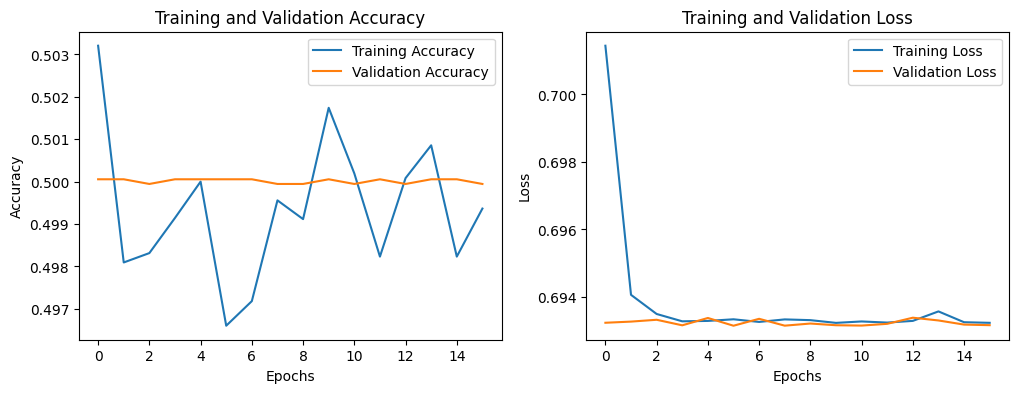

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define the RNN architecture
def build_rnn(input_shape):
    model = Sequential()

    # 1st LSTM layer
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())

    # 2nd LSTM layer
    model.add(LSTM(32, return_sequences=False, activation='tanh'))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())

    # Fully connected layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))

    # Output layer (binary classification)
    model.add(Dense(1, activation='sigmoid'))

    return model

# Input shape for RNN
input_shape = (X_train.shape[1], X_train.shape[2])  # Shape of RNN input: (time_steps, n_mfcc)

# Create the RNN model
model = build_rnn(input_shape)

# Set a custom learning rate
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

# Compile the model
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=100,  # Maximum epochs
    batch_size=128,  # Batch size
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


283/283 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step


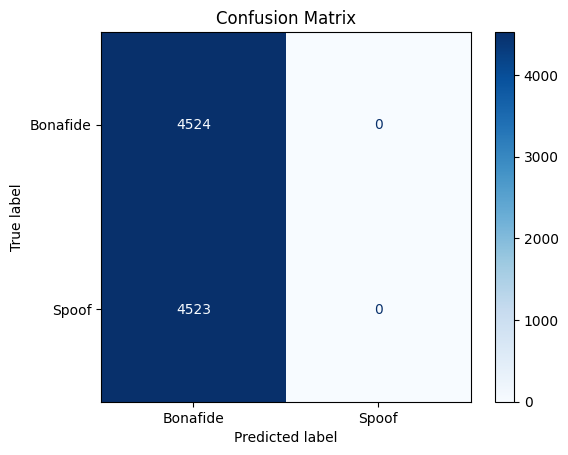

d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.00
Recall: 0.00
F1 Score: 0.00


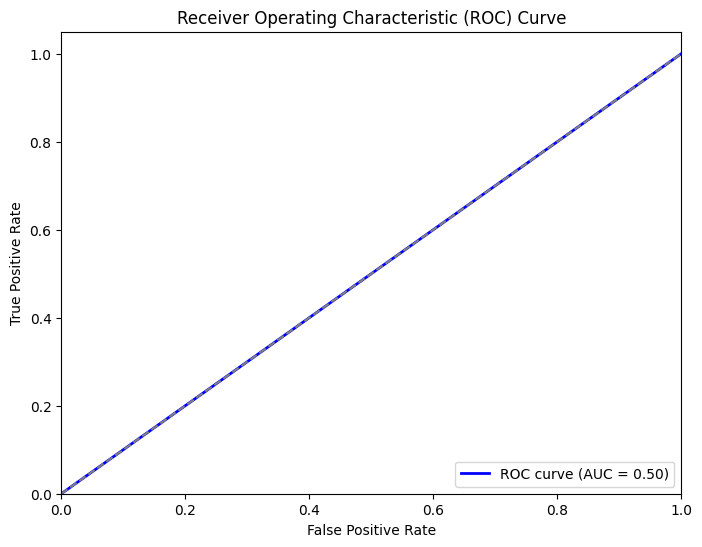

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 400, 128)       │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 400, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,329 (513.00 KB)

 Trainable params: 130,945 (511.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 532s 930ms/step - accuracy: 0.5005 - loss: 0.7291 - val_accuracy: 0.5001 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 548s 968ms/step - accuracy: 0.5027 - loss: 0.7009 - val_accuracy: 0.4999 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 533s 941ms/step - accuracy: 0.4989 - loss: 0.6967 - val_accuracy: 0.5001 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 498s 879ms/step - accuracy: 0.5029 - loss: 0.6944 - val_accuracy: 0.4999 - val_loss: 0.6969 - learning_rate: 0.0010
Epoch 5/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 491s 867ms/step - accuracy: 0.5007 - loss: 0.6951 - val_accuracy: 0.5001 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 6/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 484s 854ms/step - accuracy: 0.4961 - loss: 0.6943 - val_accuracy: 0.5003 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 7/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 494s 872ms/step -

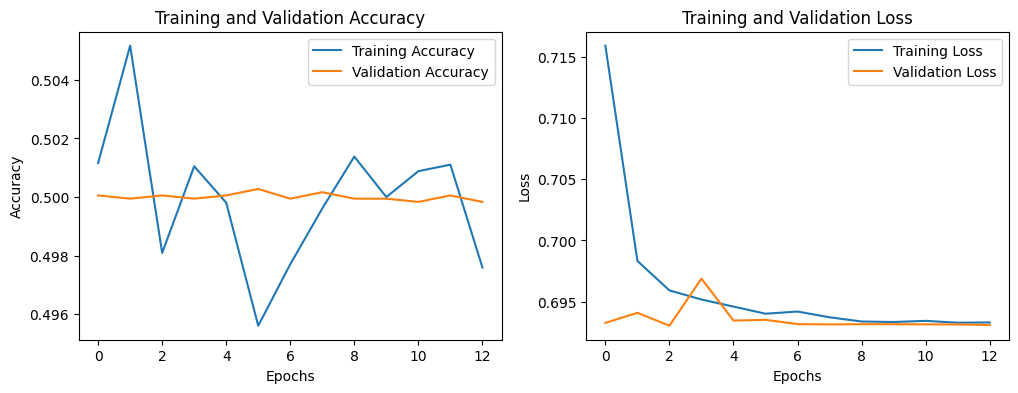

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Define the RNN architecture
def build_rnn(input_shape):
    model = Sequential()

    # 1st LSTM layer
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.3))  # Reduced dropout to prevent overfitting
    model.add(BatchNormalization())

    # 2nd LSTM layer
    model.add(LSTM(64, return_sequences=False, activation='tanh'))
    model.add(Dropout(0.3))  # Reduced dropout to prevent overfitting
    model.add(BatchNormalization())

    # Fully connected layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))  # Reduced dropout

    # Output layer (binary classification)
    model.add(Dense(1, activation='sigmoid'))

    return model

# Input shape for RNN
input_shape = (X_train.shape[1], X_train.shape[2])  # Shape of RNN input: (time_steps, n_mfcc)

# Create the RNN model
model = build_rnn(input_shape)

# Set a custom learning rate and optimizer
learning_rate = 0.001  # Reduced learning rate for better convergence
optimizer = Adam(learning_rate=learning_rate)

# Compile the model
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Add learning rate reduction if the validation loss does not improve
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model with early stopping and learning rate scheduler
history = model.fit(
    X_train, y_train,
    epochs=100,  # Maximum epochs
    batch_size=64,  # Smaller batch size for better performance
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, lr_scheduler]
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [2]:
import glob
import os
import librosa
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix


# Preprocessing functions and data loading (same as your previous code)
# These functions are reused across all models

def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

def pad_or_truncate(mfcc, max_time_steps=400):
    if mfcc.shape[1] > max_time_steps:
        return mfcc[:, :max_time_steps]
    elif mfcc.shape[1] < max_time_steps:
        padding = max_time_steps - mfcc.shape[1]
        return np.pad(mfcc, ((0, 0), (0, padding)), mode='constant')
    return mfcc

def preprocess_audio_files_rnn(audio_files, labels, n_mfcc=13, max_time_steps=400):
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file, n_mfcc=n_mfcc)
        mfcc = pad_or_truncate(mfcc, max_time_steps=max_time_steps)
        mfcc = mfcc.T
        max_value = np.max(mfcc)
        if max_value > 0:
            mfcc = mfcc / max_value
        mfcc_data.append(mfcc)
        label_data.append(1 if label == 'spoof' else 0)

    return np.array(mfcc_data), np.array(label_data)

def stratified_split_70_30(X, y, test_size=0.2, random_state=42):
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Model Building Functions

# Experiment 1: LSTM with increased complexity
def build_lstm_complex_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    model.add(LSTM(64, return_sequences=False, activation='tanh'))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Experiment 2: GRU Model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(128, return_sequences=True, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    model.add(GRU(64, return_sequences=False, activation='tanh'))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Experiment 3: Simple LSTM with fewer layers and units
def build_simple_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=False, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Experiment 4: LSTM with different dropout rates
def build_lstm_dropout_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape, activation='tanh'))
    model.add(Dropout(0.5))  # Increased dropout rate
    model.add(BatchNormalization())
    model.add(LSTM(64, return_sequences=False, activation='tanh'))
    model.add(Dropout(0.5))  # Increased dropout rate
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Experiment 5: Bidirectional LSTM
def build_bidirectional_lstm_model(input_shape):
    model = Sequential()
    model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    return model


# Function to compile, train, and evaluate the model

def compile_and_train_model(model, X_train, y_train, X_test, y_test):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[early_stopping, lr_scheduler],
        verbose=1
    )
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(conf_matrix)


# Load and preprocess the dataset
X, y = preprocess_audio_files_rnn(valid_audio_files, valid_labels, n_mfcc=13, max_time_steps=400)
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.2, random_state=42)

# Run each experiment
print("\nRunning Experiment 1: LSTM with Increased Complexity")
model_1 = build_lstm_complex_model((X_train.shape[1], X_train.shape[2]))
compile_and_train_model(model_1, X_train, y_train, X_test, y_test)

print("\nRunning Experiment 2: GRU Model")
model_2 = build_gru_model((X_train.shape[1], X_train.shape[2]))
compile_and_train_model(model_2, X_train, y_train, X_test, y_test)

print("\nRunning Experiment 3: Simple LSTM Model")
model_3 = build_simple_lstm_model((X_train.shape[1], X_train.shape[2]))
compile_and_train_model(model_3, X_train, y_train, X_test, y_test)

print("\nRunning Experiment 4: LSTM with Different Dropout Rates")
model_4 = build_lstm_dropout_model((X_train.shape[1], X_train.shape[2]))
compile_and_train_model(model_4, X_train, y_train, X_test, y_test)

print("\nRunning Experiment 5: Bidirectional LSTM Model")
model_5 = build_bidirectional_lstm_model((X_train.shape[1], X_train.shape[2]))
compile_and_train_model(model_5, X_train, y_train, X_test, y_test)



Running Experiment 1: LSTM with Increased Complexity


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 471s 1s/step - accuracy: 0.5372 - loss: 0.7707 - val_accuracy: 0.0000e+00 - val_loss: 0.9776 - learning_rate: 0.0010
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.6001 - loss: 0.6804 - val_accuracy: 0.0000e+00 - val_loss: 0.8369 - learning_rate: 0.0010
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.6229 - loss: 0.6659 - val_accuracy: 0.0000e+00 - val_loss: 0.8723 - learning_rate: 0.0010
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.6219 - loss: 0.6661 - val_accuracy: 0.0000e+00 - val_loss: 0.8767 - learning_rate: 0.0010
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6235 - loss: 0.6638
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
453/453 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.6235 - loss: 0.6638 - val_accuracy: 0.0000e+00 - val_loss: 0.8828 - learning_rate: 0.0010
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 

d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\download\fyp\.venv\Lib\site-packages\keras\src

Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.5543 - loss: 0.7428 - val_accuracy: 0.0000e+00 - val_loss: 0.8758 - learning_rate: 0.0010
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 507s 1s/step - accuracy: 0.6104 - loss: 0.6724 - val_accuracy: 0.0000e+00 - val_loss: 0.7897 - learning_rate: 0.0010
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.6232 - loss: 0.6667 - val_accuracy: 0.0000e+00 - val_loss: 0.8378 - learning_rate: 0.0010
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 524s 1s/step - accuracy: 0.6356 - loss: 0.6499 - val_accuracy: 0.6597 - val_loss: 0.7277 - learning_rate: 0.0010
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.8167 - loss: 0.4583 - val_accuracy: 0.6151 - val_loss: 1.0938 - learning_rate: 0.0010
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.8340 - loss: 0.3892 - val_accuracy: 0.6434 - val_loss: 0.8555 - learning_rate: 0.0010
Epoch 7/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.846

...

Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 131s 281ms/step - accuracy: 0.6236 - loss: 0.6651 - val_accuracy: 2.7632e-04 - val_loss: 0.9404 - learning_rate: 0.0010
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 133s 294ms/step - accuracy: 0.6253 - loss: 0.6630 - val_accuracy: 2.7632e-04 - val_loss: 0.9226 - learning_rate: 0.0010
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 127s 280ms/step - accuracy: 0.6258 - loss: 0.6625 - val_accuracy: 2.7632e-04 - val_loss: 0.9609 - learning_rate: 0.0010
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 127s 281ms/step - accuracy: 0.6251 - loss: 0.6622 - val_accuracy: 2.7632e-04 - val_loss: 0.9701 - learning_rate: 0.0010
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.6235 - loss: 0.6629
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
453/453 ━━━━━━━━━━━━━━━━━━━━ 123s 272ms/step - accuracy: 0.6235 - loss: 0.6629 - val_accuracy: 0.0000e+00 - val_loss: 0.9701 - learning_rate: 0.0010
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 123s 27

d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 450s 978ms/step - accuracy: 0.5613 - loss: 0.7591 - val_accuracy: 0.0000e+00 - val_loss: 0.8511 - learning_rate: 0.0010
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 448s 989ms/step - accuracy: 0.6036 - loss: 0.6774 - val_accuracy: 0.0000e+00 - val_loss: 0.8474 - learning_rate: 0.0010
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.6247 - loss: 0.6665 - val_accuracy: 0.0000e+00 - val_loss: 0.8163 - learning_rate: 0.0010
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 460s 1s/step - accuracy: 0.6237 - loss: 0.6647 - val_accuracy: 0.0000e+00 - val_loss: 0.8736 - learning_rate: 0.0010
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.6282 - loss: 0.6614 - val_accuracy: 0.0000e+00 - val_loss: 0.8862 - learning_rate: 0.0010
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.6195 - loss: 0.6654
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
453/453 ━━━━━━━━━━━━━━━━━━━━ 469s 1s/step - a

d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\download\fyp\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\download\fyp\.venv\Lib\site-packages\keras\src

Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 794s 2s/step - accuracy: 0.7339 - loss: 0.6082 - val_accuracy: 0.6205 - val_loss: 0.5764 - learning_rate: 0.0010
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 794s 2s/step - accuracy: 0.8092 - loss: 0.4535 - val_accuracy: 0.5948 - val_loss: 0.5845 - learning_rate: 0.0010
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 815s 2s/step - accuracy: 0.8238 - loss: 0.4051 - val_accuracy: 0.6149 - val_loss: 0.5835 - learning_rate: 0.0010
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 806s 2s/step - accuracy: 0.8244 - loss: 0.4008 - val_accuracy: 0.6296 - val_loss: 0.5431 - learning_rate: 0.0010
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 797s 2s/step - accuracy: 0.8327 - loss: 0.3798 - val_accuracy: 0.6502 - val_loss: 0.5259 - learning_rate: 0.0010
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 788s 2s/step - accuracy: 0.8385 - loss: 0.3658 - val_accuracy: 0.6733 - val_loss: 0.5410 - learning_rate: 0.0010
Epoch 7/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 819s 2s/step - accuracy: 0.8499 - loss: 0.

NameError: name 'history' is not defined

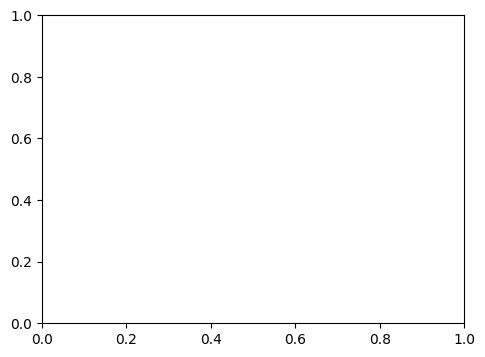

In [8]:
import matplotlib.pyplot as plt
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict the probability scores on the test set
y_pred_prob = model_5.predict(X_test).ravel()  # Flatten the array for binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)   # Convert probabilities to binary classes (0 or 1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Bonafide', 'Spoof'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Compute precision, recall, and F1 score
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

# Print precision, recall, and F1 score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
